# How the Heat Model Works, in Pictures

This notebook has no equations to follow and nothing to fit. It is the conceptual model behind
`pipetransport.heat` in plain English, with two cross-sections through the ground.

The pictures are not sketches. Every isotherm below is computed from the same steady solution the
package's kernel is built on, so what you see is what the model believes — including, at the end,
the places where it is knowingly wrong.

## The idea in four sentences

1. Water in a buried pipe drifts toward the temperature of the ground around it. How fast depends
   on how thick the pipe is, what it is made of, and how well the soil conducts.
2. The ground is not a fixed backdrop. A pipe that has been giving off heat has warmed the soil
   around it, and afterwards it is exchanging against that warmed halo instead of against
   undisturbed ground.
3. That halo takes weeks to build and weeks to fade, so the temperature at the tap depends on what
   the network was doing long before today.
4. The surface matters because the ground can dump heat there. Heat leaving a pipe spreads
   outward, and the part of it that reaches the surface leaves the system.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import Normalize

from pipetransport.heat import HeatNetwork, segment_heat_rate

CMAP = "RdYlBu_r"


def steady_field(x, z, *, depth, radius, wall, far):
    """Steady soil temperature around a buried pipe held at ``wall``, surface held at ``far``.

    The real pipe sits at ``z = -depth``; an imaginary one at ``z = +depth`` is its mirror. Their
    fields cancel exactly on the surface line, which is what "the surface holds its own
    temperature" means, and below ground the sum of the two is the answer. Normalising by
    ``ln(2 depth / radius)`` -- the package's own shape factor -- puts the pipe wall at ``wall``.
    """
    to_source = np.maximum(np.hypot(x, z + depth), radius)
    to_image = np.maximum(np.hypot(x, z - depth), 1e-9)
    return far + (wall - far) * np.log(to_image / to_source) / np.log(2.0 * depth / radius)


def conduction_arrows(ax, xx, zz, field, *, step, centres=(), floor=-np.inf, quiet=10.0):
    """Draw the conduction direction: unit arrows straight down the temperature gradient.

    Only the direction is drawn. The magnitude spans orders of magnitude between the pipe wall
    and the far field, so any single arrow scale would show one and hide the other. Where the
    gradient is in its flattest ``quiet`` per cent there is nothing to point at, and a unit arrow
    would show numerical noise at full length, so those are left blank. A percentile rather than a
    fraction of the maximum, because the maximum sits at the pipe wall and dwarfs everything else.
    """
    gz, gx = np.gradient(np.nan_to_num(field), zz[:, 0], xx[0])
    ux, uz = -gx, -gz
    with np.errstate(invalid="ignore", divide="ignore"):
        norm = np.hypot(ux, uz)
        ux, uz = ux / norm, uz / norm
    keep = np.isfinite(ux) & (zz < -0.05) & (zz > floor)
    for cx, cz, radius in centres:
        keep &= np.hypot(xx - cx, zz - cz) > radius * 1.7
    keep &= norm > np.nanpercentile(np.where(keep, norm, np.nan), quiet)
    ux, uz = np.where(keep, ux, np.nan), np.where(keep, uz, np.nan)
    ax.quiver(
        xx[::step, ::step],
        zz[::step, ::step],
        ux[::step, ::step],
        uz[::step, ::step],
        color="0.15",
        alpha=0.85,
        width=0.004,
        scale=30,
        pivot="mid",
    )

## The trick that makes the surface work: a mirror image

A buried pipe losing heat into an infinite block of soil would warm it forever. Real ground has a
surface, and the surface sheds heat to the air, which is what keeps the halo from growing without
bound.

The model handles this the way a groundwater model handles a river boundary: with a **mirror
image**. Put an imaginary pipe as far *above* the surface as the real one is below, and make it a
**sink** exactly as strong as the real one is a source. Anywhere on the surface line the two are
equidistant, so their contributions cancel and the surface stays at its own temperature — which is
precisely the boundary condition we want. Below ground, the sum of the real pipe and its imaginary
twin is the answer.

The image is a bookkeeping device, not a claim about the sky. In the figure below it is drawn
above the ground line, on a greyed strip, to make that clear.

Two details the model adds to the basic picture:

- **The image sits slightly deeper than the mirror of the real pipe.** A surface that is a *good*
  heat exchanger rather than a *perfect* one behaves like a perfect one buried a little further
  down, by the radiation length `kappa / eta`. For grass that is 0.025 / 0.41 ≈ 6 cm, so a pipe at
  1.00 m is mirrored as if it were at 1.06 m. The figure is drawn with a perfect surface, where
  the cancellation is exact.
- **The distance between the twins is what sets the resistance.** The whole steady soil resistance
  is `ln(2 d / r) / (2 pi kappa)`: the logarithm of how far apart they are, measured in pipe
  radii. Bury the pipe twice as deep and you add only `ln 2` to it.

## Is the pipe a point or a circle?

It is both, in different places, and the difference is the whole reason the first hour is modelled
separately from the rest.

- **For the steady resistance, a point.** `ln(2 d / r)` is the field of an infinitely thin line,
  read at the distance `r` where the wall would be. The radius enters only inside the logarithm.
  That is accurate as long as the pipe is much smaller than its burial depth — 0.01 % for a
  100 mm service line at a metre, 0.4 % for a 400 mm main.
- **For the transient, a genuine circle.** While the halo is still forming, a point is badly
  wrong: it says heat has already spread far away in the first minutes, when in reality it has not
  yet crossed the pipe wall. The model uses a **constant-flux cylinder** of the real outer radius,
  so the first bin of the memory is right. On hourly bins that first bin holds 86 % of the steady
  resistance for a 100 mm line and 93 % for a 400 mm main; a point would claim 94 % and 100 % —
  and the second of those leaves the coupled iteration no margin at all.
- **The mirror image stays a point, always.** It sits two effective depths away, where the
  difference between a line and a cylinder is negligible: 2e-4 of the soil resistance for a 100 mm
  service line, 3.5e-3 for a 400 mm main.

So: a circle where the geometry is felt, a point where it is not.

## Cross-section 1: looking along the pipe

The flow is *into the screen* — what you would see standing in a trench, looking down the pipe.

- **Solid contours are isotherms**, lines of equal temperature, like head contours on a
  groundwater map.
- **Arrows are the direction heat conducts**, straight across the isotherms from warm to cold,
  like flow lines crossing head contours at right angles.

Water at 20 °C, undisturbed ground at 12 °C, so heat leaves the pipe. Everything — the pipe, the
soil, the imaginary twin — is on one temperature scale, so the pipe reads as the warmest thing in
the picture, which is what it is.

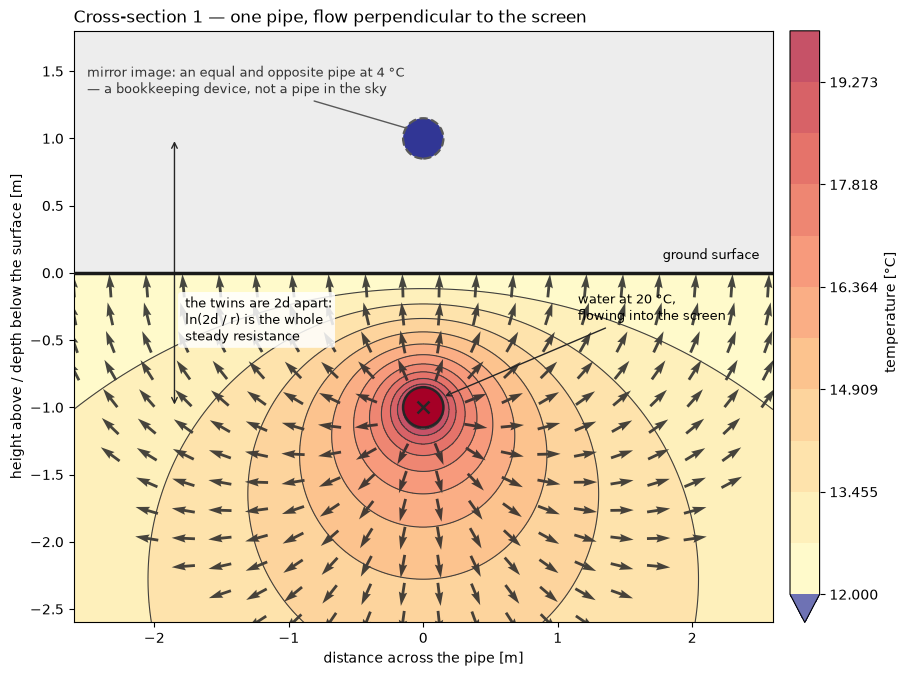

In [2]:
depth, radius, water, far = 1.0, 0.15, 20.0, 12.0
x = np.linspace(-2.6, 2.6, 460)
z = np.linspace(-2.6, 0.0, 300)
xx, zz = np.meshgrid(x, z)
field = steady_field(xx, zz, depth=depth, radius=radius, wall=water, far=far)
field[np.hypot(xx, zz + depth) < radius] = np.nan  # inside the pipe there is water, not soil

norm = Normalize(vmin=2.0 * far - water, vmax=water)  # symmetric about the far field
fig, ax = plt.subplots(figsize=(9.5, 6.8))
levels = np.linspace(far, water, 12)
shading = ax.contourf(xx, zz, field, levels=levels, cmap=CMAP, norm=norm, alpha=0.7, extend="min")
ax.contour(xx, zz, field, levels=levels, colors="0.25", linewidths=0.8)
conduction_arrows(ax, xx, zz, field, step=24, centres=[(0.0, -depth, radius)], quiet=12.0)

# the real pipe, coloured by the water it carries
ax.add_patch(
    plt.Circle((0.0, -depth), radius, facecolor=plt.get_cmap(CMAP)(norm(water)), edgecolor="0.15", lw=1.8, zorder=6)
)
ax.plot(0.0, -depth, marker="x", ms=8, mew=1.8, color="0.15", zorder=7)
ax.annotate(
    f"water at {water:.0f} °C,\nflowing into the screen",
    xy=(radius * 0.95, -depth + radius * 0.5),
    xytext=(1.15, -0.35),
    arrowprops={"arrowstyle": "->", "color": "0.15"},
    fontsize=9,
    zorder=7,
)

# the mirror image: as cold as the real pipe is warm, and not a real object
ax.axhspan(0.0, 1.8, color="0.93", zorder=1)
ax.add_patch(
    plt.Circle(
        (0.0, depth),
        radius,
        facecolor=plt.get_cmap(CMAP)(norm(2 * far - water)),
        edgecolor="0.35",
        lw=1.6,
        ls="--",
        zorder=6,
    )
)
ax.annotate(
    f"mirror image: an equal and opposite pipe at {2 * far - water:.0f} °C\n"
    "— a bookkeeping device, not a pipe in the sky",
    xy=(radius * 0.9, depth),
    xytext=(-2.5, 1.55),
    arrowprops={"arrowstyle": "->", "color": "0.35"},
    fontsize=9,
    color="0.2",
    va="top",
)
ax.annotate("", xy=(-1.85, depth), xytext=(-1.85, -depth), arrowprops={"arrowstyle": "<->", "color": "0.15"})
ax.text(
    -1.8,
    -0.35,
    " the twins are 2d apart:\n ln(2d / r) is the whole\n steady resistance",
    fontsize=9,
    va="center",
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "none"},
)
ax.axhline(0.0, color="0.1", lw=2.5, zorder=5)
ax.text(2.5, 0.08, "ground surface", fontsize=9, va="bottom", ha="right", zorder=7)

fig.colorbar(shading, ax=ax, pad=0.02, label="temperature [°C]")
ax.set_xlabel("distance across the pipe [m]")
ax.set_ylabel("height above / depth below the surface [m]")
ax.set_title("Cross-section 1 — one pipe, flow perpendicular to the screen", loc="left")
ax.set_aspect("equal")
ax.set_ylim(-2.6, 1.8)
fig.tight_layout()

Three things to read off this picture.

**The isotherms crowd near the pipe.** Almost the whole 8 K drop happens within a couple of pipe
diameters. That is why the soil dominates the resistance of a small pipe: the heat has to squeeze
out through a thin shell before it has any room.

**The arrows fan upward.** Heat does not spread evenly in all directions — the surface is a sink,
so more goes up than down. Deeper burial weakens that, which is the `ln(2d/r)` again.

**No isotherm crosses the surface.** That is the mirror image doing its job.

The package does not solve this field at run time. It needs only two numbers out of it: how much
the soil resists heat leaving the pipe, and how that resistance *grows* while the halo is still
building. Everything else here is summarised into those two.

## Cross-section 2: along the pipeline, from grassland to pavement

Now turn ninety degrees: the flow is *left to right along the screen*, and we follow one pipeline
as it passes out from under grassland and continues under pavement.

Pavement is warmer at depth than grass — it absorbs more sun and evaporates nothing — so the water
is chasing a target that steps up as it crosses. Two panels: what happens to the water over three
kilometres, and what the ground looks like right at the boundary.

In [3]:
# The exchange rate is the package's own, for a 100 mm grass service line buried a metre.
probe = HeatNetwork(
    segments=pd.DataFrame(
        {
            "from": ["P"],
            "to": ["T"],
            "length": [3000.0],
            "diameter": [0.1],
            "cover": ["grass"],
            "alpha": [0.05],
            "kappa_soil": [0.025],
            "depth": [1.0],
            "eta": [0.41],
        },
        index=["s"],
    ),
    source="P",
)
h = float(segment_heat_rate(network=probe).iloc[0])
velocity = 0.10 * 86400.0  # m/day, a quiet service line
relax = velocity / h  # metres to cover 63 % of the way to a new target

soil_grass, soil_paved, inlet = 11.0, 17.0, 8.0
distance = np.linspace(-1500.0, 1500.0, 1201)


def target_at(dist, depth_m):
    """Undisturbed soil temperature under a step change of surface cover.

    The harmonic extension of a step: at the surface it is one value or the other, and with depth
    the change smears out over a length of order the depth itself.
    """
    with np.errstate(divide="ignore", invalid="ignore"):
        blend = 0.5 + np.arctan(dist / np.maximum(depth_m, 1e-9)) / np.pi
    return soil_grass + (soil_paved - soil_grass) * blend


target = target_at(distance, 1.0)
# March the water along the pipe: it relaxes toward the local target as it goes.
water_along = np.empty_like(distance)
water_along[0] = inlet
for i in range(1, len(distance)):
    keep = np.exp(-(distance[i] - distance[i - 1]) / relax)
    water_along[i] = target[i] + (water_along[i - 1] - target[i]) * keep

print(f"exchange rate h = {h:.2f} 1/day at a water speed of {velocity / 86400:.2f} m/s")
print(f"relaxation length v/h = {relax:.0f} m -- the water needs kilometres, not metres")
print(f"inlet {inlet:.1f} C -> {water_along[-1]:.2f} C after 3 km")
print(f"soil at pipe depth: {soil_grass:.1f} C under grass, {soil_paved:.1f} C under pavement")

exchange rate h = 5.34 1/day at a water speed of 0.10 m/s
relaxation length v/h = 1619 m -- the water needs kilometres, not metres
inlet 8.0 C -> 14.15 C after 3 km
soil at pipe depth: 11.0 C under grass, 17.0 C under pavement


(-2.4, 0.34)

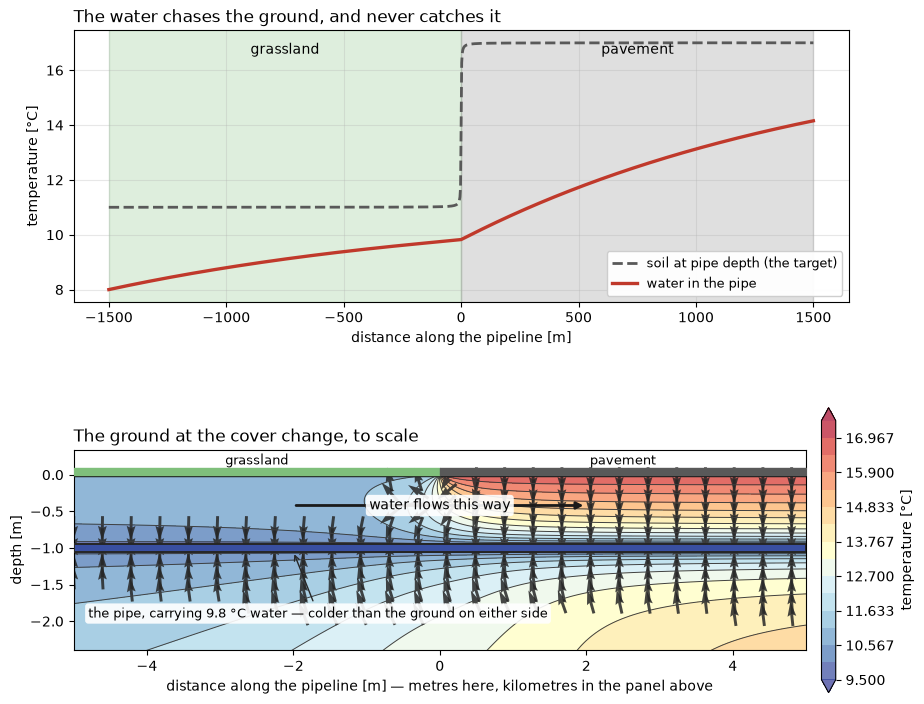

In [4]:
fig, (top, bottom) = plt.subplots(2, 1, figsize=(10, 8.6), height_ratios=[1.0, 1.05], gridspec_kw={"hspace": 0.38})

top.axvspan(-1500, 0, color="#7fbf7b", alpha=0.25)
top.axvspan(0, 1500, color="0.5", alpha=0.25)
top.plot(distance, target, color="0.35", lw=2.0, ls="--", label="soil at pipe depth (the target)")
top.plot(distance, water_along, color="#c0392b", lw=2.4, label="water in the pipe")
top.text(-750, soil_paved - 0.4, "grassland", ha="center", fontsize=10)
top.text(750, soil_paved - 0.4, "pavement", ha="center", fontsize=10)
top.set_xlabel("distance along the pipeline [m]")
top.set_ylabel("temperature [°C]")
top.set_title("The water chases the ground, and never catches it", loc="left")
top.legend(loc="lower right", fontsize=9, framealpha=0.95)
top.grid(alpha=0.3)

# the ground near the boundary, true to scale
window, pipe_depth, pipe_radius = 5.0, 1.0, 0.05
x = np.linspace(-window, window, 460)
z = np.linspace(-2.4, 0.0, 260)
xx, zz = np.meshgrid(x, z)
base = target_at(xx, -zz)

# Each slice of ground conducts on its own -- which is exactly what the model assumes.
drive = np.interp(xx[0], distance, water_along) - target_at(xx[0], pipe_depth)
radial = np.log(np.maximum(np.abs(zz - pipe_depth), 1e-9) / np.maximum(np.abs(zz + pipe_depth), pipe_radius))
field = base + drive[None, :] * radial / np.log(2.0 * pipe_depth / pipe_radius)
field[np.abs(zz + pipe_depth) < pipe_radius] = np.nan

norm2 = Normalize(vmin=soil_grass - 1.5, vmax=soil_paved + 0.5)
levels = np.linspace(soil_grass - 1.5, soil_paved + 0.5, 16)
shading = bottom.contourf(xx, zz, field, levels=levels, cmap=CMAP, norm=norm2, alpha=0.7, extend="both")
bottom.contour(xx, zz, field, levels=levels, colors="0.25", linewidths=0.7)
conduction_arrows(bottom, xx, zz, field, step=18, floor=-2.2, quiet=30.0)

water_here = float(np.interp(0.0, distance, water_along))
bottom.add_patch(
    plt.Rectangle(
        (-window, -pipe_depth - pipe_radius),
        2 * window,
        2 * pipe_radius,
        facecolor=plt.get_cmap(CMAP)(norm2(water_here)),
        edgecolor="0.15",
        lw=1.4,
        zorder=6,
    )
)
bottom.annotate(
    f"the pipe, carrying {water_here:.1f} °C water — colder than the ground on either side",
    xy=(-2.0, -pipe_depth - pipe_radius),
    xytext=(-4.8, -1.95),
    arrowprops={"arrowstyle": "->", "color": "0.15"},
    fontsize=9,
    zorder=7,
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.9, "edgecolor": "none"},
)
bottom.annotate(
    "",
    xy=(2.0, -0.42),
    xytext=(-2.0, -0.42),
    arrowprops={"arrowstyle": "-|>", "color": "0.1", "lw": 2.0},
    zorder=7,
)
bottom.text(
    0.0,
    -0.42,
    "water flows this way",
    fontsize=10,
    ha="center",
    va="center",
    zorder=8,
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.9, "edgecolor": "none"},
)
bottom.axhline(0.0, color="0.1", lw=2.5, zorder=5)
bottom.fill_between([-window, 0.0], 0.0, 0.09, color="#7fbf7b", zorder=6)
bottom.fill_between([0.0, window], 0.0, 0.09, color="0.35", zorder=6)
bottom.text(-window / 2, 0.14, "grassland", ha="center", fontsize=9)
bottom.text(window / 2, 0.14, "pavement", ha="center", fontsize=9)
fig.colorbar(shading, ax=bottom, pad=0.02, fraction=0.035, label="temperature [°C]")
bottom.set_xlabel("distance along the pipeline [m] — metres here, kilometres in the panel above")
bottom.set_ylabel("depth [m]")
bottom.set_title("The ground at the cover change, to scale", loc="left")
bottom.set_aspect("equal")
bottom.set_ylim(-2.4, 0.34)

The top panel answers "what happens to water flowing under pavement rather than grassland". The
water is always behind: it needs a couple of kilometres to make most of the way to a new target,
so it crosses well into the paved stretch still carrying the grassland's temperature, and it never
quite arrives. A pipe is a low-pass filter on the ground it is buried in — which is why a tap's
temperature reflects the whole route rather than the last hundred metres of it.

The bottom panel is the same moment seen from the ground's side, and note the scale: the cover
change that took kilometres to matter for the water reaches down to the pipe over **a metre or
two**. Right at the boundary the ground just above the pipe is warmer than the water inside it, so
the arrows there point down and inward — the water is being warmed — while a few hundred metres
upstream it was still losing heat to cooler ground.

### The assumption this picture makes visible

Look at the isotherms immediately around the pipe: they are drawn as if each slice of ground
conducts on its own, with no heat flowing **along** the pipeline. That is exactly what the model
assumes — one wall-flux history per pipe, independent soil columns — and it is why the halo can
change abruptly from one segment to the next. Real ground would smear that step over a metre or
so. It is the assumption tracked in issue #32, and the reason to declare a long pipe as a chain of
shorter segments when the ground under it changes.

## What happens to the water, in words

Follow one parcel from the plant to a tap.

1. **It enters a pipe.** From that moment it starts drifting toward the temperature of the ground
   around that pipe — quickly in a thin pipe, slowly in a wide one, and over kilometres rather
   than metres either way.
2. **It gives up (or takes on) heat as it goes.** That heat does not vanish; it goes into the soil
   shell around that particular pipe, and stays in the model's books.
3. **It passes into the next pipe**, which may be shallower, thinner, or under a different cover.
   It starts drifting toward a new target, from wherever the last pipe left it.
4. **It arrives at the tap**, having been part of the way to several different ground temperatures.

Meanwhile, and much more slowly:

5. **The soil remembers.** Every pipe's shell holds the heat that has been put into it, decaying
   away over weeks. Tomorrow's water meets today's leftovers.

## The one thing that is easy to get wrong

When does a pipe give up its heat?

The tempting answer is "when the water comes out" — take the temperature drop between the ends and
book it at the moment of delivery. That is wrong in a way that only shows up when water sits
still. A branch that draws nothing overnight is exchanging heat all night; if the whole night is
charged to the few minutes of the morning flush, that instant looks vastly more energetic than
anything real, and the model can deliver temperatures nothing in the inputs could produce.

The package books the heat **over the hours it actually happens in**, by tracking how much heat
each pipe is holding, bin by bin. A pipe with no flow still loses heat, exactly as it does in the
ground. That is the difference between a model that settles down when you describe a pipe in finer
pieces and one that drifts further away.

## What the model does not claim

- **One memory per pipe.** The real halo is thicker where the water is hottest, near the inlet.
  The model gives the whole pipe one shell. Split a long pipe into pieces if that matters (#32).
- **No conduction along the pipeline.** Each slice of ground is independent, as the bottom panel
  above draws it.
- **Neighbours ignored.** Two pipes in one trench warm each other; here they do not.
- **The ground is uniform under each cover.** No stones, no water table, no seasonal moisture.
- **The weather is yours to supply.** The model will not guess it, and at a metre down it is the
  *seasonal* weather that matters, not yesterday's.

Each of these is stated with numbers in the user guide's *Assumptions* page, and
`02_Network_Temperature.ipynb` puts the whole thing to work on a real network.